In [1]:
import json
import logging
from utils.cross_validation_siamese_raw import CrossValidationSiameseRaw, TrainingProcedureParameters, TrainingParameters
from utils.gait_parameters_extractor import CoordinatesIdx
from pathlib import Path


with open("./datasets/mocap/dataset_mocap_cycles_split.json", "r") as file:
    mocap_cycles = json.load(file)

with open("./datasets/yolo/dataset_yolo26_triang_cycles_split.json", "r") as file:
    yolo_cycles = json.load(file)

with open("./datasets/yolo/dataset_yolo26_triang_best_cameras_cycles_split.json", "r") as file:
    yolo_best_cams_cycles = json.load(file)

with open("./datasets/yolo/dataset_yolo26_triang_cycles_split_butterworth.json", "r") as file:
    yolo_cycles_butterworth = json.load(file)

with open("./datasets/yolo/dataset_yolo26_triang_best_cameras_cycles_split_butterworth.json", "r") as file:
    yolo_best_cams_cycles_butterworth = json.load(file)

In [2]:
tpp = TrainingProcedureParameters(
    tp_conv1d = TrainingParameters(
        learning_rate = 1e-6,
        batch_size = 32,
        n_epochs = 100,
    ),
    tp_lstm = TrainingParameters(
        learning_rate = 1e-5,
        batch_size = 32,
        n_epochs = 150,
    )
)

tpp

TrainingProcedureParameters(tp_conv1d=TrainingParameters(learning_rate=1e-06, batch_size=32, n_epochs=100), tp_lstm=TrainingParameters(learning_rate=1e-05, batch_size=32, n_epochs=150), n_folds=4)

2026-02-09 00:04:56,428 - mocap - INFO - Preparing cycles and participant labels...
2026-02-09 00:05:10,093 - mocap - INFO - [Iteration 1/4]
2026-02-09 00:05:10,095 - mocap - INFO - [Iteration 2/4]
2026-02-09 00:05:10,144 - mocap - INFO - Train dataset size: 4452
2026-02-09 00:05:10,172 - mocap - INFO - Using device: cuda
2026-02-09 00:05:14,812 - mocap - INFO - Epoch 1, Train Loss: 4.211981349331992
2026-02-09 00:05:15,648 - mocap - INFO - Epoch 2, Train Loss: 1.8614362112113407
2026-02-09 00:05:16,456 - mocap - INFO - Epoch 3, Train Loss: 0.8386164467249598
2026-02-09 00:05:17,286 - mocap - INFO - Epoch 4, Train Loss: 0.4290256053209305
2026-02-09 00:05:18,117 - mocap - INFO - Epoch 5, Train Loss: 0.26879163395081246
2026-02-09 00:05:18,972 - mocap - INFO - Epoch 6, Train Loss: 0.1962394679231303
2026-02-09 00:05:19,816 - mocap - INFO - Epoch 7, Train Loss: 0.15522180811635086
2026-02-09 00:05:20,647 - mocap - INFO - Epoch 8, Train Loss: 0.13098180179617236
2026-02-09 00:05:21,476 - 

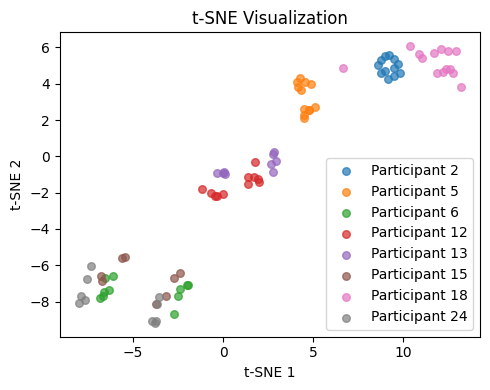

2026-02-09 00:06:43,601 - mocap - INFO - Test set size for rank classification: 87
2026-02-09 00:06:43,602 - mocap - INFO - Starting cross-validated model evaluation...
2026-02-09 00:06:43,603 - mocap - INFO - Model        | Rank-1     | Rank-2     | Rank-3    
2026-02-09 00:06:43,604 - mocap - INFO - -------------------------------------------------------
2026-02-09 00:06:43,627 - mocap - INFO - k-NN eucl    | 0.8150     | 0.9647     | 0.9765
2026-02-09 00:06:43,648 - mocap - INFO - k-NN manh    | 0.8275     | 0.9647     | 0.9765
2026-02-09 00:06:43,686 - mocap - INFO - SVM          | 0.8843     | 0.9647     | 1.0000
2026-02-09 00:06:44,721 - mocap - INFO - MLP          | 0.8961     | 0.9647     | 0.9882
2026-02-09 00:06:44,743 - mocap - INFO - NB           | 0.8621     | 0.9307     | 0.9889
2026-02-09 00:06:44,799 - mocap - INFO - LR           | 0.8961     | 0.9647     | 0.9882
2026-02-09 00:06:45,428 - mocap - INFO - RF           | 0.8856     | 0.9647     | 1.0000
2026-02-09 00:06:4

In [3]:
cv = CrossValidationSiameseRaw(
    sequence_cycles = mocap_cycles, 
    coordinates_idx = CoordinatesIdx(2, 0, 1), 
    log_level = logging.INFO,
    logger_name = 'mocap',
)
cv.count_participants_samples()
cv.perform_training_with_rank_classification(
    n_folds = tpp.n_folds,
    siamese_nn_type = "conv1d",
    learning_rate = tpp.tp_conv1d.learning_rate,
    batch_size = tpp.tp_conv1d.batch_size,
    n_epochs = tpp.tp_conv1d.n_epochs,
    embedding_size = 10,
    tsne_perplexity = 20,
    show_plot = True, 
)

2026-02-09 00:06:49,114 - mocap - INFO - Preparing cycles and participant labels...
2026-02-09 00:07:04,394 - mocap - INFO - [Iteration 1/4]
2026-02-09 00:07:04,395 - mocap - INFO - [Iteration 2/4]
2026-02-09 00:07:04,455 - mocap - INFO - Train dataset size: 4452
2026-02-09 00:07:04,456 - mocap - INFO - Using device: cuda
2026-02-09 00:07:05,603 - mocap - INFO - Epoch 1, Train Loss: 0.3702995539775917
2026-02-09 00:07:06,694 - mocap - INFO - Epoch 2, Train Loss: 0.35184147251503806
2026-02-09 00:07:07,756 - mocap - INFO - Epoch 3, Train Loss: 0.33063530038510053
2026-02-09 00:07:08,852 - mocap - INFO - Epoch 4, Train Loss: 0.30126336589455605
2026-02-09 00:07:09,951 - mocap - INFO - Epoch 5, Train Loss: 0.26825935116836
2026-02-09 00:07:11,067 - mocap - INFO - Epoch 6, Train Loss: 0.23726416102477482
2026-02-09 00:07:12,172 - mocap - INFO - Epoch 7, Train Loss: 0.21023471733289106
2026-02-09 00:07:13,255 - mocap - INFO - Epoch 8, Train Loss: 0.18477967168603623
2026-02-09 00:07:14,366 

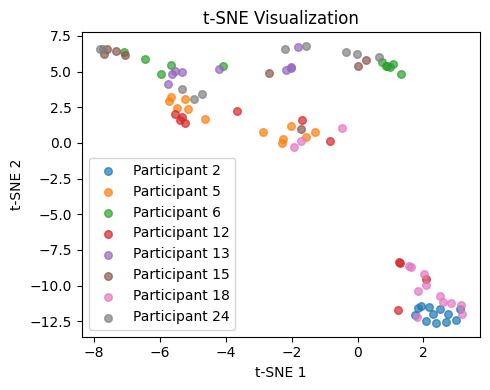

2026-02-09 00:09:41,119 - mocap - INFO - Test set size for rank classification: 87
2026-02-09 00:09:41,120 - mocap - INFO - Starting cross-validated model evaluation...
2026-02-09 00:09:41,121 - mocap - INFO - Model        | Rank-1     | Rank-2     | Rank-3    
2026-02-09 00:09:41,121 - mocap - INFO - -------------------------------------------------------
2026-02-09 00:09:41,143 - mocap - INFO - k-NN eucl    | 0.6092     | 0.8392     | 0.8850
2026-02-09 00:09:41,163 - mocap - INFO - k-NN manh    | 0.5745     | 0.8503     | 0.8850
2026-02-09 00:09:41,199 - mocap - INFO - SVM          | 0.4719     | 0.7941     | 0.9307
2026-02-09 00:09:42,452 - mocap - INFO - MLP          | 0.7582     | 0.8856     | 0.9431
2026-02-09 00:09:42,474 - mocap - INFO - NB           | 0.5183     | 0.7824     | 0.8170
2026-02-09 00:09:42,522 - mocap - INFO - LR           | 0.4837     | 0.7941     | 0.8967
2026-02-09 00:09:43,164 - mocap - INFO - RF           | 0.6902     | 0.8745     | 0.9314
2026-02-09 00:09:4

In [4]:
cv = CrossValidationSiameseRaw(
    sequence_cycles = mocap_cycles, 
    coordinates_idx = CoordinatesIdx(2, 0, 1), 
    log_level = logging.INFO,
    logger_name = 'mocap',
)

cv.perform_training_with_rank_classification(
    n_folds = tpp.n_folds,
    siamese_nn_type = "lstm",
    learning_rate = tpp.tp_lstm.learning_rate,
    batch_size = tpp.tp_lstm.batch_size,
    n_epochs = tpp.tp_lstm.n_epochs,
    embedding_size = 10,
    tsne_perplexity = 20,
    show_plot = True, 
)

2026-02-09 00:09:46,995 - yolo - INFO - Preparing cycles and participant labels...
2026-02-09 00:09:59,087 - yolo - INFO - [Iteration 1/4]
2026-02-09 00:09:59,088 - yolo - INFO - [Iteration 2/4]
2026-02-09 00:09:59,118 - yolo - INFO - Train dataset size: 3126
2026-02-09 00:09:59,119 - yolo - INFO - Using device: cuda
2026-02-09 00:09:59,847 - yolo - INFO - Epoch 1, Train Loss: 6.908137211994249
2026-02-09 00:10:00,612 - yolo - INFO - Epoch 2, Train Loss: 4.260660861219678
2026-02-09 00:10:01,336 - yolo - INFO - Epoch 3, Train Loss: 2.7979423172619877
2026-02-09 00:10:02,063 - yolo - INFO - Epoch 4, Train Loss: 1.958712572954139
2026-02-09 00:10:02,776 - yolo - INFO - Epoch 5, Train Loss: 1.4447058472706347
2026-02-09 00:10:03,500 - yolo - INFO - Epoch 6, Train Loss: 1.0945155401619113
2026-02-09 00:10:04,237 - yolo - INFO - Epoch 7, Train Loss: 0.8374525126145811
2026-02-09 00:10:04,935 - yolo - INFO - Epoch 8, Train Loss: 0.6496976101580931
2026-02-09 00:10:05,633 - yolo - INFO - Epoc

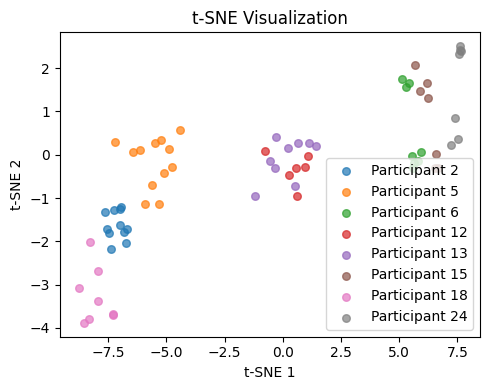

2026-02-09 00:11:07,423 - yolo - INFO - Test set size for rank classification: 68
2026-02-09 00:11:07,424 - yolo - INFO - Starting cross-validated model evaluation...
2026-02-09 00:11:07,424 - yolo - INFO - Model        | Rank-1     | Rank-2     | Rank-3    
2026-02-09 00:11:07,425 - yolo - INFO - -------------------------------------------------------
2026-02-09 00:11:07,447 - yolo - INFO - k-NN eucl    | 0.7923     | 0.9253     | 0.9703
2026-02-09 00:11:07,467 - yolo - INFO - k-NN manh    | 0.7330     | 0.9396     | 0.9703
2026-02-09 00:11:07,501 - yolo - INFO - SVM          | 0.7934     | 1.0000     | 1.0000
2026-02-09 00:11:08,565 - yolo - INFO - MLP          | 0.8198     | 0.9846     | 0.9846
2026-02-09 00:11:08,588 - yolo - INFO - NB           | 0.8352     | 0.9110     | 0.9857
2026-02-09 00:11:08,633 - yolo - INFO - LR           | 0.8341     | 0.9846     | 1.0000
2026-02-09 00:11:09,247 - yolo - INFO - RF           | 0.8659     | 1.0000     | 1.0000
2026-02-09 00:11:12,648 - yol

In [5]:
cv = CrossValidationSiameseRaw(
    sequence_cycles = yolo_cycles, 
    coordinates_idx = CoordinatesIdx(0, 1, 2), 
    log_level = logging.INFO,
    logger_name = 'yolo',
)
cv.perform_training_with_rank_classification(
    n_folds = tpp.n_folds,
    siamese_nn_type = "conv1d",
    learning_rate = tpp.tp_conv1d.learning_rate,
    batch_size = tpp.tp_conv1d.batch_size,
    n_epochs = tpp.tp_conv1d.n_epochs,
    embedding_size = 10,
    tsne_perplexity = 20,
    show_plot = True, 
)

2026-02-09 00:11:12,682 - yolo - INFO - Preparing cycles and participant labels...
2026-02-09 00:11:24,882 - yolo - INFO - [Iteration 1/4]
2026-02-09 00:11:24,884 - yolo - INFO - [Iteration 2/4]
2026-02-09 00:11:24,916 - yolo - INFO - Train dataset size: 3126
2026-02-09 00:11:24,918 - yolo - INFO - Using device: cuda
2026-02-09 00:11:25,687 - yolo - INFO - Epoch 1, Train Loss: 0.36054690790419675
2026-02-09 00:11:26,475 - yolo - INFO - Epoch 2, Train Loss: 0.3487425937640424
2026-02-09 00:11:27,250 - yolo - INFO - Epoch 3, Train Loss: 0.3324887630890827
2026-02-09 00:11:28,008 - yolo - INFO - Epoch 4, Train Loss: 0.32228076184282495
2026-02-09 00:11:28,760 - yolo - INFO - Epoch 5, Train Loss: 0.307725121628265
2026-02-09 00:11:29,517 - yolo - INFO - Epoch 6, Train Loss: 0.29482120457960637
2026-02-09 00:11:30,281 - yolo - INFO - Epoch 7, Train Loss: 0.28149441948958803
2026-02-09 00:11:31,010 - yolo - INFO - Epoch 8, Train Loss: 0.26671672794891865
2026-02-09 00:11:31,780 - yolo - INFO

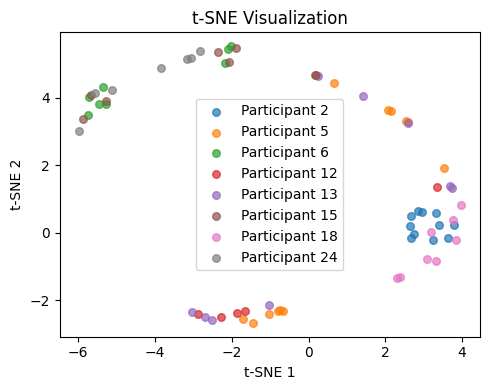

2026-02-09 00:13:15,980 - yolo - INFO - Test set size for rank classification: 68
2026-02-09 00:13:15,981 - yolo - INFO - Starting cross-validated model evaluation...
2026-02-09 00:13:15,981 - yolo - INFO - Model        | Rank-1     | Rank-2     | Rank-3    
2026-02-09 00:13:15,982 - yolo - INFO - -------------------------------------------------------
2026-02-09 00:13:16,004 - yolo - INFO - k-NN eucl    | 0.4703     | 0.6582     | 0.8967
2026-02-09 00:13:16,031 - yolo - INFO - k-NN manh    | 0.4846     | 0.6890     | 0.9110
2026-02-09 00:13:16,063 - yolo - INFO - SVM          | 0.2659     | 0.6330     | 0.9132
2026-02-09 00:13:17,258 - yolo - INFO - MLP          | 0.5275     | 0.8077     | 0.9099
2026-02-09 00:13:17,280 - yolo - INFO - NB           | 0.5132     | 0.7022     | 0.9396
2026-02-09 00:13:17,331 - yolo - INFO - LR           | 0.3956     | 0.6890     | 0.8681
2026-02-09 00:13:17,975 - yolo - INFO - RF           | 0.4956     | 0.7473     | 0.9110
2026-02-09 00:13:21,459 - yol

In [6]:
cv = CrossValidationSiameseRaw(
    sequence_cycles = yolo_cycles, 
    coordinates_idx = CoordinatesIdx(0, 1, 2), 
    log_level = logging.INFO,
    logger_name = 'yolo',
)

cv.perform_training_with_rank_classification(
    n_folds = tpp.n_folds,
    siamese_nn_type = "lstm",
    learning_rate = tpp.tp_lstm.learning_rate,
    batch_size = tpp.tp_lstm.batch_size,
    n_epochs = tpp.tp_lstm.n_epochs,
    embedding_size = 10,
    tsne_perplexity = 20,
    show_plot = True, 
)

2026-02-09 00:13:21,494 - yolo_best_cameras - INFO - Preparing cycles and participant labels...
2026-02-09 00:13:33,885 - yolo_best_cameras - INFO - [Iteration 1/4]
2026-02-09 00:13:33,886 - yolo_best_cameras - INFO - [Iteration 2/4]
2026-02-09 00:13:33,933 - yolo_best_cameras - INFO - Train dataset size: 3416
2026-02-09 00:13:33,934 - yolo_best_cameras - INFO - Using device: cuda
2026-02-09 00:13:34,720 - yolo_best_cameras - INFO - Epoch 1, Train Loss: 7.544242952471581
2026-02-09 00:13:35,496 - yolo_best_cameras - INFO - Epoch 2, Train Loss: 5.141745053719137
2026-02-09 00:13:36,260 - yolo_best_cameras - INFO - Epoch 3, Train Loss: 3.5082347916665477
2026-02-09 00:13:37,023 - yolo_best_cameras - INFO - Epoch 4, Train Loss: 2.3953159133964608
2026-02-09 00:13:37,759 - yolo_best_cameras - INFO - Epoch 5, Train Loss: 1.6871075641329043
2026-02-09 00:13:38,536 - yolo_best_cameras - INFO - Epoch 6, Train Loss: 1.2349614342239414
2026-02-09 00:13:39,304 - yolo_best_cameras - INFO - Epoch 7

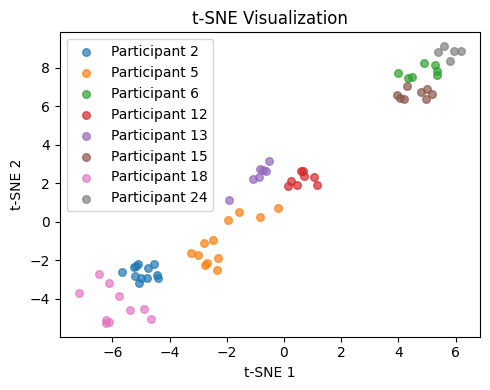

2026-02-09 00:14:49,325 - yolo_best_cameras - INFO - Test set size for rank classification: 69
2026-02-09 00:14:49,326 - yolo_best_cameras - INFO - Starting cross-validated model evaluation...
2026-02-09 00:14:49,327 - yolo_best_cameras - INFO - Model        | Rank-1     | Rank-2     | Rank-3    
2026-02-09 00:14:49,327 - yolo_best_cameras - INFO - -------------------------------------------------------
2026-02-09 00:14:49,349 - yolo_best_cameras - INFO - k-NN eucl    | 0.8099     | 0.9560     | 0.9846
2026-02-09 00:14:49,370 - yolo_best_cameras - INFO - k-NN manh    | 0.7670     | 0.9857     | 1.0000
2026-02-09 00:14:49,404 - yolo_best_cameras - INFO - SVM          | 0.9143     | 0.9714     | 1.0000
2026-02-09 00:14:50,326 - yolo_best_cameras - INFO - MLP          | 0.9286     | 0.9714     | 1.0000
2026-02-09 00:14:50,348 - yolo_best_cameras - INFO - NB           | 0.9143     | 0.9857     | 1.0000
2026-02-09 00:14:50,397 - yolo_best_cameras - INFO - LR           | 0.8703     | 0.9560 

In [7]:
cv = CrossValidationSiameseRaw(
    sequence_cycles=yolo_best_cams_cycles, 
    coordinates_idx=CoordinatesIdx(0, 1, 2), 
    log_level=logging.INFO,
    logger_name = 'yolo_best_cameras',
)
cv.perform_training_with_rank_classification(
    n_folds = tpp.n_folds,
    siamese_nn_type = "conv1d",
    learning_rate = tpp.tp_conv1d.learning_rate,
    batch_size = tpp.tp_conv1d.batch_size,
    n_epochs = tpp.tp_conv1d.n_epochs,
    embedding_size = 10,
    tsne_perplexity = 20,
    show_plot = True, 
)

2026-02-09 00:14:54,586 - yolo_best_cameras - INFO - Preparing cycles and participant labels...
2026-02-09 00:15:07,287 - yolo_best_cameras - INFO - [Iteration 1/4]
2026-02-09 00:15:07,288 - yolo_best_cameras - INFO - [Iteration 2/4]
2026-02-09 00:15:07,325 - yolo_best_cameras - INFO - Train dataset size: 3416
2026-02-09 00:15:07,326 - yolo_best_cameras - INFO - Using device: cuda
2026-02-09 00:15:08,188 - yolo_best_cameras - INFO - Epoch 1, Train Loss: 0.3508412390947342
2026-02-09 00:15:09,020 - yolo_best_cameras - INFO - Epoch 2, Train Loss: 0.33597386189710315
2026-02-09 00:15:09,866 - yolo_best_cameras - INFO - Epoch 3, Train Loss: 0.32582739190520527
2026-02-09 00:15:10,709 - yolo_best_cameras - INFO - Epoch 4, Train Loss: 0.30226437649994253
2026-02-09 00:15:11,577 - yolo_best_cameras - INFO - Epoch 5, Train Loss: 0.2798256690257064
2026-02-09 00:15:12,436 - yolo_best_cameras - INFO - Epoch 6, Train Loss: 0.25594181950404266
2026-02-09 00:15:13,274 - yolo_best_cameras - INFO - E

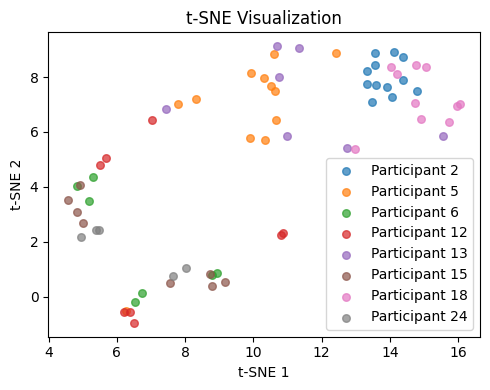

2026-02-09 00:17:11,303 - yolo_best_cameras - INFO - Test set size for rank classification: 69
2026-02-09 00:17:11,304 - yolo_best_cameras - INFO - Starting cross-validated model evaluation...
2026-02-09 00:17:11,305 - yolo_best_cameras - INFO - Model        | Rank-1     | Rank-2     | Rank-3    
2026-02-09 00:17:11,305 - yolo_best_cameras - INFO - -------------------------------------------------------
2026-02-09 00:17:11,335 - yolo_best_cameras - INFO - k-NN eucl    | 0.4912     | 0.7681     | 0.9121
2026-02-09 00:17:11,356 - yolo_best_cameras - INFO - k-NN manh    | 0.5330     | 0.7374     | 0.9121
2026-02-09 00:17:11,387 - yolo_best_cameras - INFO - SVM          | 0.4198     | 0.7956     | 0.9418
2026-02-09 00:17:12,608 - yolo_best_cameras - INFO - MLP          | 0.6209     | 0.8692     | 0.9418
2026-02-09 00:17:12,629 - yolo_best_cameras - INFO - NB           | 0.5484     | 0.8396     | 0.9275
2026-02-09 00:17:12,682 - yolo_best_cameras - INFO - LR           | 0.4484     | 0.7253 

In [8]:
cv = CrossValidationSiameseRaw(
    sequence_cycles=yolo_best_cams_cycles, 
    coordinates_idx=CoordinatesIdx(0, 1, 2), 
    log_level=logging.INFO,
    logger_name = 'yolo_best_cameras',
)

cv.perform_training_with_rank_classification(
    n_folds = tpp.n_folds,
    siamese_nn_type = "lstm",
    learning_rate = tpp.tp_lstm.learning_rate,
    batch_size = tpp.tp_lstm.batch_size,
    n_epochs = tpp.tp_lstm.n_epochs,
    embedding_size = 10,
    tsne_perplexity = 20,
    show_plot = True, 
)

2026-02-09 00:17:16,898 - yolo_butterworth - INFO - Preparing cycles and participant labels...
2026-02-09 00:17:27,718 - yolo_butterworth - INFO - [Iteration 1/4]
2026-02-09 00:17:27,720 - yolo_butterworth - INFO - [Iteration 2/4]
2026-02-09 00:17:27,748 - yolo_butterworth - INFO - Train dataset size: 2634
2026-02-09 00:17:27,749 - yolo_butterworth - INFO - Using device: cuda
2026-02-09 00:17:28,367 - yolo_butterworth - INFO - Epoch 1, Train Loss: 9.98475470600358
2026-02-09 00:17:28,977 - yolo_butterworth - INFO - Epoch 2, Train Loss: 6.861672769109886
2026-02-09 00:17:29,590 - yolo_butterworth - INFO - Epoch 3, Train Loss: 4.7274747153362595
2026-02-09 00:17:30,196 - yolo_butterworth - INFO - Epoch 4, Train Loss: 3.356499522565359
2026-02-09 00:17:30,814 - yolo_butterworth - INFO - Epoch 5, Train Loss: 2.37405216765691
2026-02-09 00:17:31,416 - yolo_butterworth - INFO - Epoch 6, Train Loss: 1.753551925521299
2026-02-09 00:17:32,042 - yolo_butterworth - INFO - Epoch 7, Train Loss: 1.3

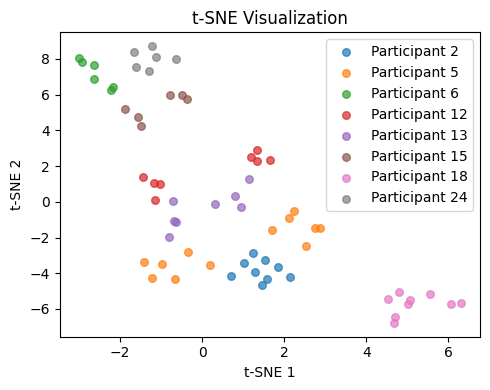

2026-02-09 00:18:28,530 - yolo_butterworth - INFO - Test set size for rank classification: 64
2026-02-09 00:18:28,531 - yolo_butterworth - INFO - Starting cross-validated model evaluation...
2026-02-09 00:18:28,532 - yolo_butterworth - INFO - Model        | Rank-1     | Rank-2     | Rank-3    
2026-02-09 00:18:28,532 - yolo_butterworth - INFO - -------------------------------------------------------
2026-02-09 00:18:28,553 - yolo_butterworth - INFO - k-NN eucl    | 0.8449     | 0.9846     | 1.0000
2026-02-09 00:18:28,574 - yolo_butterworth - INFO - k-NN manh    | 0.8756     | 1.0000     | 1.0000
2026-02-09 00:18:28,611 - yolo_butterworth - INFO - SVM          | 0.9526     | 1.0000     | 1.0000
2026-02-09 00:18:29,442 - yolo_butterworth - INFO - MLP          | 0.9385     | 1.0000     | 1.0000
2026-02-09 00:18:29,463 - yolo_butterworth - INFO - NB           | 0.9359     | 0.9679     | 1.0000
2026-02-09 00:18:29,504 - yolo_butterworth - INFO - LR           | 0.9526     | 0.9833     | 1.00

In [9]:
cv = CrossValidationSiameseRaw(
    sequence_cycles=yolo_cycles_butterworth, 
    coordinates_idx=CoordinatesIdx(0, 1, 2), 
    log_level=logging.INFO,
    logger_name = 'yolo_butterworth',
)
cv.perform_training_with_rank_classification(
    n_folds = tpp.n_folds,
    siamese_nn_type = "conv1d",
    learning_rate = tpp.tp_conv1d.learning_rate,
    batch_size = tpp.tp_conv1d.batch_size,
    n_epochs = tpp.tp_conv1d.n_epochs,
    embedding_size = 10,
    tsne_perplexity = 20,
    show_plot = True, 
)

2026-02-09 00:18:33,488 - yolo_butterworth - INFO - Preparing cycles and participant labels...
2026-02-09 00:18:44,695 - yolo_butterworth - INFO - [Iteration 1/4]
2026-02-09 00:18:44,696 - yolo_butterworth - INFO - [Iteration 2/4]
2026-02-09 00:18:44,722 - yolo_butterworth - INFO - Train dataset size: 2634
2026-02-09 00:18:44,723 - yolo_butterworth - INFO - Using device: cuda
2026-02-09 00:18:45,388 - yolo_butterworth - INFO - Epoch 1, Train Loss: 0.3493409250155989
2026-02-09 00:18:46,042 - yolo_butterworth - INFO - Epoch 2, Train Loss: 0.3346880173467728
2026-02-09 00:18:46,693 - yolo_butterworth - INFO - Epoch 3, Train Loss: 0.3197410413658763
2026-02-09 00:18:47,356 - yolo_butterworth - INFO - Epoch 4, Train Loss: 0.30757577771163847
2026-02-09 00:18:48,034 - yolo_butterworth - INFO - Epoch 5, Train Loss: 0.29039180530122966
2026-02-09 00:18:48,683 - yolo_butterworth - INFO - Epoch 6, Train Loss: 0.28582314967391004
2026-02-09 00:18:49,337 - yolo_butterworth - INFO - Epoch 7, Train

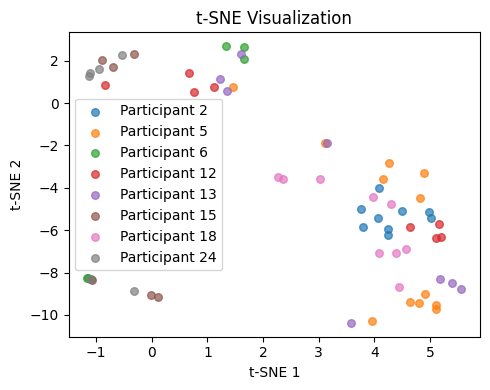

2026-02-09 00:20:18,349 - yolo_butterworth - INFO - Test set size for rank classification: 64
2026-02-09 00:20:18,350 - yolo_butterworth - INFO - Starting cross-validated model evaluation...
2026-02-09 00:20:18,350 - yolo_butterworth - INFO - Model        | Rank-1     | Rank-2     | Rank-3    
2026-02-09 00:20:18,351 - yolo_butterworth - INFO - -------------------------------------------------------
2026-02-09 00:20:18,373 - yolo_butterworth - INFO - k-NN eucl    | 0.5026     | 0.8295     | 0.9064
2026-02-09 00:20:18,392 - yolo_butterworth - INFO - k-NN manh    | 0.4859     | 0.8449     | 0.9064
2026-02-09 00:20:18,428 - yolo_butterworth - INFO - SVM          | 0.2962     | 0.5321     | 0.7346
2026-02-09 00:20:19,571 - yolo_butterworth - INFO - MLP          | 0.5795     | 0.8436     | 0.9218
2026-02-09 00:20:19,592 - yolo_butterworth - INFO - NB           | 0.5641     | 0.7359     | 0.8141
2026-02-09 00:20:19,636 - yolo_butterworth - INFO - LR           | 0.3910     | 0.7179     | 0.84

In [10]:
cv = CrossValidationSiameseRaw(
    sequence_cycles=yolo_cycles_butterworth, 
    coordinates_idx=CoordinatesIdx(0, 1, 2), 
    log_level=logging.INFO,
    logger_name = 'yolo_butterworth',
)

cv.perform_training_with_rank_classification(
    n_folds = tpp.n_folds,
    siamese_nn_type = "lstm",
    learning_rate = tpp.tp_lstm.learning_rate,
    batch_size = tpp.tp_lstm.batch_size,
    n_epochs = tpp.tp_lstm.n_epochs,
    embedding_size = 10,
    tsne_perplexity = 20,
    show_plot = True, 
)

2026-02-09 00:20:23,845 - yolo_best_cameras_butterworth - INFO - Preparing cycles and participant labels...
2026-02-09 00:20:35,035 - yolo_best_cameras_butterworth - INFO - [Iteration 1/4]
2026-02-09 00:20:35,036 - yolo_best_cameras_butterworth - INFO - [Iteration 2/4]
2026-02-09 00:20:35,062 - yolo_best_cameras_butterworth - INFO - Train dataset size: 2650
2026-02-09 00:20:35,063 - yolo_best_cameras_butterworth - INFO - Using device: cuda
2026-02-09 00:20:35,668 - yolo_best_cameras_butterworth - INFO - Epoch 1, Train Loss: 4.049761283828552
2026-02-09 00:20:36,284 - yolo_best_cameras_butterworth - INFO - Epoch 2, Train Loss: 2.6612674766276254
2026-02-09 00:20:36,891 - yolo_best_cameras_butterworth - INFO - Epoch 3, Train Loss: 1.7180756416665501
2026-02-09 00:20:37,490 - yolo_best_cameras_butterworth - INFO - Epoch 4, Train Loss: 1.0638086802988167
2026-02-09 00:20:38,102 - yolo_best_cameras_butterworth - INFO - Epoch 5, Train Loss: 0.6802106154970375
2026-02-09 00:20:38,709 - yolo_b

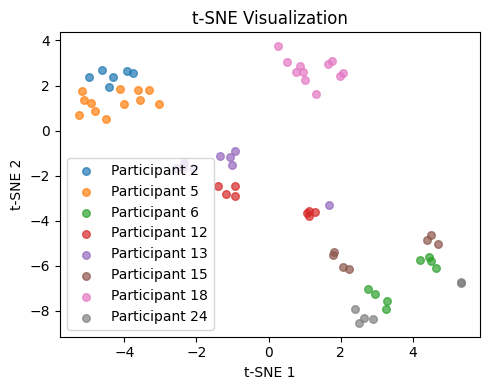

2026-02-09 00:21:34,961 - yolo_best_cameras_butterworth - INFO - Test set size for rank classification: 67
2026-02-09 00:21:34,962 - yolo_best_cameras_butterworth - INFO - Starting cross-validated model evaluation...
2026-02-09 00:21:34,963 - yolo_best_cameras_butterworth - INFO - Model        | Rank-1     | Rank-2     | Rank-3    
2026-02-09 00:21:34,964 - yolo_best_cameras_butterworth - INFO - -------------------------------------------------------
2026-02-09 00:21:34,991 - yolo_best_cameras_butterworth - INFO - k-NN eucl    | 0.8824     | 0.9857     | 1.0000
2026-02-09 00:21:35,011 - yolo_best_cameras_butterworth - INFO - k-NN manh    | 0.8692     | 0.9703     | 0.9857
2026-02-09 00:21:35,046 - yolo_best_cameras_butterworth - INFO - SVM          | 0.9264     | 0.9857     | 0.9857
2026-02-09 00:21:36,097 - yolo_best_cameras_butterworth - INFO - MLP          | 0.9703     | 0.9857     | 0.9857
2026-02-09 00:21:36,130 - yolo_best_cameras_butterworth - INFO - NB           | 0.9418     | 

In [11]:
cv = CrossValidationSiameseRaw(
    sequence_cycles = yolo_best_cams_cycles_butterworth, 
    coordinates_idx = CoordinatesIdx(0, 1, 2), 
    log_level = logging.INFO,
    logger_name = 'yolo_best_cameras_butterworth',
)
cv.perform_training_with_rank_classification(
    n_folds = tpp.n_folds,
    siamese_nn_type = "conv1d",
    learning_rate = tpp.tp_conv1d.learning_rate,
    batch_size = tpp.tp_conv1d.batch_size,
    n_epochs = tpp.tp_conv1d.n_epochs,
    embedding_size = 10,
    tsne_perplexity = 20,
    show_plot = True, 
)

2026-02-09 00:21:40,303 - yolo_best_cameras_butterworth - INFO - Preparing cycles and participant labels...
2026-02-09 00:21:51,588 - yolo_best_cameras_butterworth - INFO - [Iteration 1/4]
2026-02-09 00:21:51,589 - yolo_best_cameras_butterworth - INFO - [Iteration 2/4]
2026-02-09 00:21:51,616 - yolo_best_cameras_butterworth - INFO - Train dataset size: 2650
2026-02-09 00:21:51,618 - yolo_best_cameras_butterworth - INFO - Using device: cuda
2026-02-09 00:21:52,304 - yolo_best_cameras_butterworth - INFO - Epoch 1, Train Loss: 0.35508437293121614
2026-02-09 00:21:52,988 - yolo_best_cameras_butterworth - INFO - Epoch 2, Train Loss: 0.33298908712634123
2026-02-09 00:21:53,653 - yolo_best_cameras_butterworth - INFO - Epoch 3, Train Loss: 0.31278615723173303
2026-02-09 00:21:54,309 - yolo_best_cameras_butterworth - INFO - Epoch 4, Train Loss: 0.29113235800381165
2026-02-09 00:21:54,994 - yolo_best_cameras_butterworth - INFO - Epoch 5, Train Loss: 0.2707423327198948
2026-02-09 00:21:55,637 - y

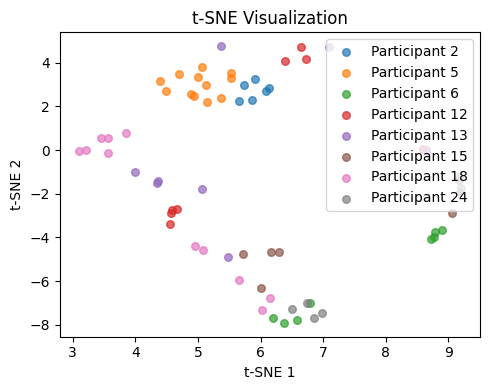

2026-02-09 00:23:25,509 - yolo_best_cameras_butterworth - INFO - Test set size for rank classification: 67
2026-02-09 00:23:25,510 - yolo_best_cameras_butterworth - INFO - Starting cross-validated model evaluation...
2026-02-09 00:23:25,510 - yolo_best_cameras_butterworth - INFO - Model        | Rank-1     | Rank-2     | Rank-3    
2026-02-09 00:23:25,511 - yolo_best_cameras_butterworth - INFO - -------------------------------------------------------
2026-02-09 00:23:25,533 - yolo_best_cameras_butterworth - INFO - k-NN eucl    | 0.6582     | 0.8352     | 0.9407
2026-02-09 00:23:25,553 - yolo_best_cameras_butterworth - INFO - k-NN manh    | 0.6143     | 0.8198     | 0.9549
2026-02-09 00:23:25,586 - yolo_best_cameras_butterworth - INFO - SVM          | 0.5363     | 0.7297     | 0.9242
2026-02-09 00:23:26,771 - yolo_best_cameras_butterworth - INFO - MLP          | 0.7132     | 0.8626     | 0.9242
2026-02-09 00:23:26,793 - yolo_best_cameras_butterworth - INFO - NB           | 0.5670     | 

In [12]:
cv = CrossValidationSiameseRaw(
    sequence_cycles = yolo_best_cams_cycles_butterworth, 
    coordinates_idx = CoordinatesIdx(0, 1, 2), 
    log_level = logging.INFO,
    logger_name = 'yolo_best_cameras_butterworth',
)

cv.perform_training_with_rank_classification(
    n_folds = tpp.n_folds,
    siamese_nn_type = "lstm",
    learning_rate = tpp.tp_lstm.learning_rate,
    batch_size = tpp.tp_lstm.batch_size,
    n_epochs = tpp.tp_lstm.n_epochs,
    embedding_size = 10,
    tsne_perplexity = 20,
    show_plot = True, 
)